# Zadanie 3 — Model ML i Explainable AI

## 3.0 Importy i dane

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, GroupKFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.feature_selection import SelectKBest, f_regression
import shap
import warnings
warnings.filterwarnings('ignore')

features = pd.read_csv('../data/processed/features.csv')
print(f'Wczytano features: {features.shape}')
print(f'Dzielnice: {features["district_id"].nunique()}, sklepów per dzielnica:')
print(features['district_name'].value_counts().head(10).to_string())
features.head()

Wczytano features: (50, 99)
Dzielnice: 14, sklepów per dzielnica:
district_name
Kraków              14
Katowice             8
Gliwice              8
Bytom                5
Sosnowiec            3
Olkusz               2
powiat wielicki      2
Tychy                2
Rybnik               1
Dąbrowa Górnicza     1


,location_id,lat,lng,monthly_revenue,district_id,district_name,traces_500m,traces_2000m,devices_500m,devices_2000m,...,convenience_count_2000m,zabka_count_1000m,zabka_count_2000m,discount_count_3000m,competitors_total_2000m,competitors_total_3000m,brand_diversity_2000m,comp_decay_total,comp_decay_zabka,comp_decay_discount
0,LOC_001,50.226272,19.072973,245633.74,2401.0,Katowice,17537,60503,275,912,...,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.822327,0.822327,0.000000
1,LOC_002,50.299999,18.674625,333393.33,2403.0,Gliwice,27611,326556,654,3216,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.086505,0.076730,0.009775
2,LOC_003,50.042894,19.968676,296109.69,2404.0,Kraków,6312,161913,341,2954,...,2.0,1.0,2.0,0.0,3.0,6.0,2.0,1.609825,1.070756,0.000000
3,LOC_004,50.130954,19.607709,197099.19,2408.0,Olkusz,923,11721,29,307,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
4,LOC_005,50.351594,18.894944,292786.56,2412.0,Bytom,29446,253366,408,2665,...,1.0,0.0,1.0,0.0,2.0,2.0,2.0,0.439808,0.142044,0.000000


## 3.1 Target i cechy

In [2]:
META_COLS = {'location_id', 'lat', 'lng', 'monthly_revenue', 'district_id', 'district_name'}
feature_cols = [c for c in features.columns if c not in META_COLS]
print(f'Liczba cech: {len(feature_cols)}')

X_full = features[feature_cols].copy()
y_full = np.log1p(features['monthly_revenue'])
groups_full = features['district_id'].values

# Identyfikacja LOC_033 — analizujemy z/bez
loc033_mask = (features['location_id'] == 'LOC_033').values
print(f'LOC_033 obecny: {loc033_mask.sum() == 1} (revenue = {features.loc[loc033_mask, "monthly_revenue"].iloc[0]:,.0f} PLN)')

# Cechy wymagające log-transformacji (silnie skośne licznikowe). Stosujemy w pipeline (przed scaler)
LOG_FEATURE_PREFIXES = (
    'traces_', 'devices_', 'population_total', 'households_count',
    'buildings_count', 'total_building_area', 'poi_total', 'poi_decay_total',
    'restaurant_count', 'restaurant_decay', 'school_count', 'school_decay',
    'pharmacy_count', 'pharmacy_decay', 'bank_count', 'bank_decay',
    'hospital_count', 'hospital_decay', 'mall_count', 'mall_decay',
    'park_count', 'park_decay',
    'competitors_total', 'zabka_count', 'convenience_count', 'discount_count',
    'comp_decay_', 'population_per_km2', 'households_per_km2',
    'buildings_density_per_km2',
)
log_feature_idx = [i for i, c in enumerate(feature_cols)
                   if any(c.startswith(p) for p in LOG_FEATURE_PREFIXES)]
print(f'Cechy log-transformowane w pipeline: {len(log_feature_idx)}/{len(feature_cols)}')

print(f'\nSkośność y_raw:  {features["monthly_revenue"].skew():.2f}')
print(f'Skośność log(y): {y_full.skew():.2f}')

Liczba cech: 93
LOC_033 obecny: True (revenue = 50,000 PLN)
Cechy log-transformowane w pipeline: 56/93

Skośność y_raw:  1.15
Skośność log(y): -0.99


## 3.2 Korelacje (eksploracja, nie używamy do selekcji)

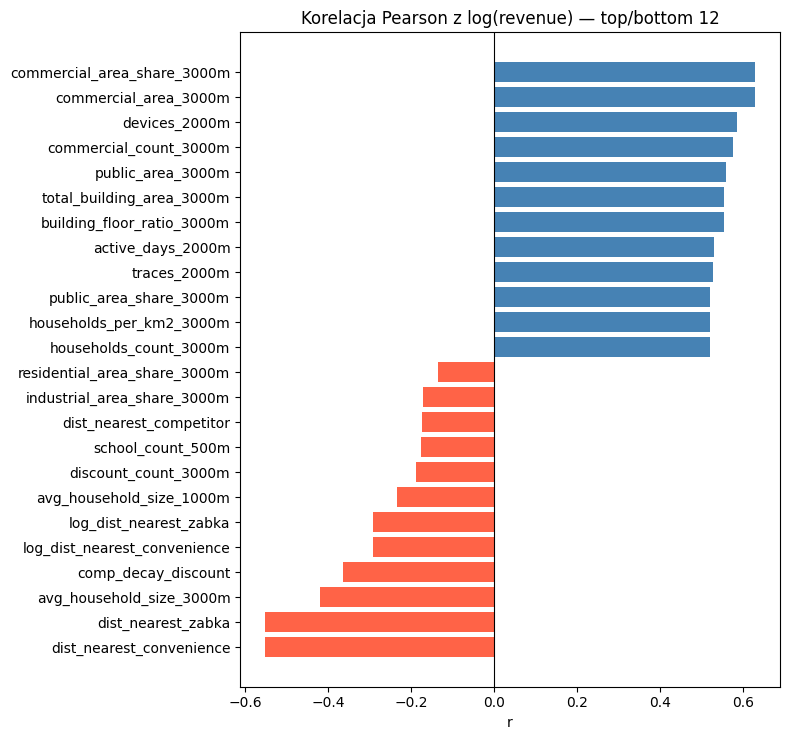

In [3]:
# Tylko do oglądu — nie używane do selekcji cech (ta odbywa się w pipeline, fold-by-fold)
corr_with_target = X_full.corrwith(y_full).sort_values()
top_n = 25
fig, ax = plt.subplots(figsize=(8, top_n * 0.3))
top = pd.concat([corr_with_target.head(top_n // 2), corr_with_target.tail(top_n // 2)])
colors = ['tomato' if v < 0 else 'steelblue' for v in top]
ax.barh(top.index, top.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Korelacja Pearson z log(revenue) — top/bottom {top_n // 2}')
ax.set_xlabel('r')
plt.tight_layout()
plt.show()

In [4]:
from sklearn.base import clone

# Log1p deterministyczny dla skośnych liczników — poza pipeline (nie zależy od y)
log_cols = [feature_cols[i] for i in log_feature_idx]
X_log = X_full.copy()
X_log[log_cols] = np.log1p(X_log[log_cols].clip(lower=0))
X_log_arr = X_log.values
y_arr = y_full.values
y_raw_arr = features['monthly_revenue'].values
groups_arr = groups_full

# Inner CV używane przez RidgeCV/LassoCV/ElasticNetCV — 5-fold KFold (n_train ~40)
INNER_CV = KFold(n_splits=5, shuffle=True, random_state=0)

def make_pipelines(k_select):
    """k_select: liczba cech do wybrania przez SelectKBest (filtr per fold)."""
    return {
        'Dummy':      Pipeline([('dummy', DummyRegressor(strategy='mean'))]),
        'Ridge':      Pipeline([
            ('select', SelectKBest(f_regression, k=k_select)),
            ('scaler', StandardScaler()),
            ('est', RidgeCV(alphas=np.logspace(-2, 3, 30), cv=INNER_CV)),
        ]),
        'Lasso':      Pipeline([
            ('select', SelectKBest(f_regression, k=k_select)),
            ('scaler', StandardScaler()),
            ('est', LassoCV(alphas=np.logspace(-3, 1, 30), cv=INNER_CV, max_iter=10000, random_state=0)),
        ]),
        'ElasticNet': Pipeline([
            ('select', SelectKBest(f_regression, k=k_select)),
            ('scaler', StandardScaler()),
            ('est', ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
                                 alphas=np.logspace(-3, 1, 20),
                                 cv=INNER_CV, max_iter=10000, random_state=0)),
        ]),
        'XGBoost':    Pipeline([
            ('select', SelectKBest(f_regression, k=k_select)),
            ('est', XGBRegressor(
                n_estimators=80, max_depth=2, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                reg_alpha=1.0, reg_lambda=2.0, min_child_weight=3,
                random_state=0, verbosity=0,
            )),
        ]),
    }

def spatial_oof_predict(estimator, X, y, groups, n_splits=5, n_seeds=10):
    """Multi-seed GroupKFold OOF predictions. Zwraca macierz (n_seeds, n_samples)."""
    preds = np.zeros((n_seeds, len(y)))
    for s in range(n_seeds):
        rng = np.random.RandomState(s)
        uniq = np.array(sorted(set(groups)))
        rng.shuffle(uniq)
        group_to_fold = {g: i % n_splits for i, g in enumerate(uniq)}
        fold_idx = np.array([group_to_fold[g] for g in groups])
        for f in range(n_splits):
            tr, te = fold_idx != f, fold_idx == f
            if te.sum() == 0:
                continue
            est = clone(estimator)
            est.fit(X[tr], y[tr])
            preds[s, te] = est.predict(X[te])
    return preds

print('Pipeline factory + spatial CV gotowe.')

Pipeline factory + spatial CV gotowe.


## 3.3 Ewaluacja — Spatial CV × multi-seed × {z LOC_033, bez LOC_033}

In [5]:
def evaluate(X, y, y_raw_pln, groups, k_select=12, n_seeds=10, label=''):
    """Zwraca DataFrame z mean/std R² (na log-y) oraz RMSE w PLN dla każdego modelu."""
    pipelines = make_pipelines(k_select=min(k_select, X.shape[1]))
    rows = []
    seed_preds = {}
    for name, pipe in pipelines.items():
        preds = spatial_oof_predict(pipe, X, y, groups, n_splits=5, n_seeds=n_seeds)
        # R² per seed (na log-y), uśredniamy
        r2s = [r2_score(y, preds[s]) for s in range(n_seeds)]
        # RMSE w PLN — uśrednione predykcje, expm1
        pred_pln_mean = np.expm1(preds.mean(axis=0))
        rmse_pln = np.sqrt(mean_squared_error(y_raw_pln, pred_pln_mean))
        rows.append({
            'model': name,
            'R²_mean': np.mean(r2s),
            'R²_std':  np.std(r2s),
            'RMSE_PLN': rmse_pln,
        })
        seed_preds[name] = preds
    return pd.DataFrame(rows).set_index('model'), seed_preds

print('=== Z LOC_033 (n=50) ===')
results_full, preds_full = evaluate(X_log_arr, y_arr, y_raw_arr, groups_arr,
                                     k_select=12, n_seeds=10, label='full')
print(results_full.round(3).to_string())

print('\n=== Bez LOC_033 (n=49) ===')
keep = ~loc033_mask
results_clean, preds_clean = evaluate(
    X_log_arr[keep], y_arr[keep], y_raw_arr[keep], groups_arr[keep],
    k_select=12, n_seeds=10, label='clean'
)
print(results_clean.round(3).to_string())

# Wybór modelu: najlepszy mean R² na zbiorze BEZ outliera (oczekiwana ekspansja na "normalnych" lokalizacjach)
best_name = results_clean['R²_mean'].idxmax()
print(f'\n→ Wybrany model: {best_name}  (R²={results_clean.loc[best_name, "R²_mean"]:.3f} ± {results_clean.loc[best_name, "R²_std"]:.3f}, RMSE={results_clean.loc[best_name, "RMSE_PLN"]:,.0f} PLN)')

=== Z LOC_033 (n=50) ===
            R²_mean  R²_std    RMSE_PLN
model                                  
Dummy        -0.093   0.026  113879.030
Ridge         0.155   0.072   95433.494
Lasso         0.113   0.048   97399.351
ElasticNet    0.110   0.061   96803.754
XGBoost       0.151   0.047  100372.116

=== Bez LOC_033 (n=49) ===
            R²_mean  R²_std    RMSE_PLN
model                                  
Dummy        -0.082   0.035  108097.386
Ridge         0.199   0.104   91246.612
Lasso         0.165   0.131   93756.439
ElasticNet    0.175   0.107   93447.016
XGBoost       0.183   0.054   96765.624

→ Wybrany model: Ridge  (R²=0.199 ± 0.104, RMSE=91,247 PLN)


In [6]:
## 3.4b Tuning k_select — nested spatial CV
k_candidates = [5, 7, 9, 12, 15, 20]
k_rows = []
print('Tuning k_select dla Ridge (spatial CV × 10 seedów)...')
for k in k_candidates:
    ev_k, _ = evaluate(
        X_log_arr[keep], y_arr[keep], y_raw_arr[keep], groups_arr[keep],
        k_select=k, n_seeds=10
    )
    k_rows.append({'k': k,
                   'R2_mean': ev_k.loc['Ridge', 'R²_mean'],
                   'R2_std':  ev_k.loc['Ridge', 'R²_std'],
                   'RMSE':    ev_k.loc['Ridge', 'RMSE_PLN']})
    print(f'  k={k:2d}: R²={k_rows[-1]["R2_mean"]:.3f} ± {k_rows[-1]["R2_std"]:.3f}  RMSE={k_rows[-1]["RMSE"]:,.0f} PLN')

k_df = pd.DataFrame(k_rows).set_index('k')
best_k = int(k_df['R2_mean'].idxmax())
print(f'\n→ Najlepsze k = {best_k}  '
      f'(R²={k_df.loc[best_k, "R2_mean"]:.3f} ± {k_df.loc[best_k, "R2_std"]:.3f})')


Tuning k_select dla Ridge (spatial CV × 10 seedów)...
  k= 5: R²=0.205 ± 0.075  RMSE=90,456 PLN
  k= 7: R²=0.216 ± 0.043  RMSE=90,374 PLN
  k= 9: R²=0.199 ± 0.067  RMSE=91,282 PLN
  k=12: R²=0.199 ± 0.104  RMSE=91,247 PLN
  k=15: R²=0.186 ± 0.122  RMSE=92,028 PLN
  k=20: R²=0.175 ± 0.075  RMSE=92,887 PLN

→ Najlepsze k = 7  (R²=0.216 ± 0.043)


In [7]:
## 3.4c Ensemble Ridge + XGBoost (OOF mean)
# Sprawdzamy, czy blendowanie zmniejsza wariancję bez straty R²
best_results_k, best_preds_k = evaluate(
    X_log_arr[keep], y_arr[keep], y_raw_arr[keep], groups_arr[keep],
    k_select=best_k, n_seeds=10
)
print('Wyniki dla optymalnego k_select:')
print(best_results_k.round(3).to_string())

ridge_oof = best_preds_k['Ridge'].mean(axis=0)
xgb_oof   = best_preds_k['XGBoost'].mean(axis=0)

print('\nEnsemble Ridge + XGBoost (różne wagi):')
for w in [0.3, 0.5, 0.7]:
    ens = w * ridge_oof + (1 - w) * xgb_oof
    r2  = r2_score(y_arr[keep], ens)
    rmse = np.sqrt(mean_squared_error(y_raw_arr[keep], np.expm1(ens)))
    print(f'  Ridge×{w:.1f} + XGB×{1-w:.1f}: R²={r2:.3f}  RMSE={rmse:,.0f} PLN')

# Wybór finalnego modelu: Ridge z najlepszym k (wyższy R²) lub XGBoost (niższy std)
final_model_name = best_results_k['R²_mean'].idxmax()
final_k = best_k
print(f'\n→ Finalny model: {final_model_name}, k={final_k}')
print(f'   CV R² = {best_results_k.loc[final_model_name, "R²_mean"]:.3f} '
      f'± {best_results_k.loc[final_model_name, "R²_std"]:.3f}')
print(f'   CV RMSE = {best_results_k.loc[final_model_name, "RMSE_PLN"]:,.0f} PLN')


Wyniki dla optymalnego k_select:
            R²_mean  R²_std    RMSE_PLN
model                                  
Dummy        -0.082   0.035  108097.386
Ridge         0.216   0.043   90374.470
Lasso         0.172   0.096   94556.095
ElasticNet    0.185   0.089   93756.962
XGBoost       0.165   0.052   97274.084

Ensemble Ridge + XGBoost (różne wagi):
  Ridge×0.3 + XGB×0.7: R²=0.227  RMSE=95,081 PLN
  Ridge×0.5 + XGB×0.5: R²=0.245  RMSE=93,673 PLN
  Ridge×0.7 + XGB×0.3: R²=0.260  RMSE=92,313 PLN

→ Finalny model: Ridge, k=7
   CV R² = 0.216 ± 0.043
   CV RMSE = 90,374 PLN


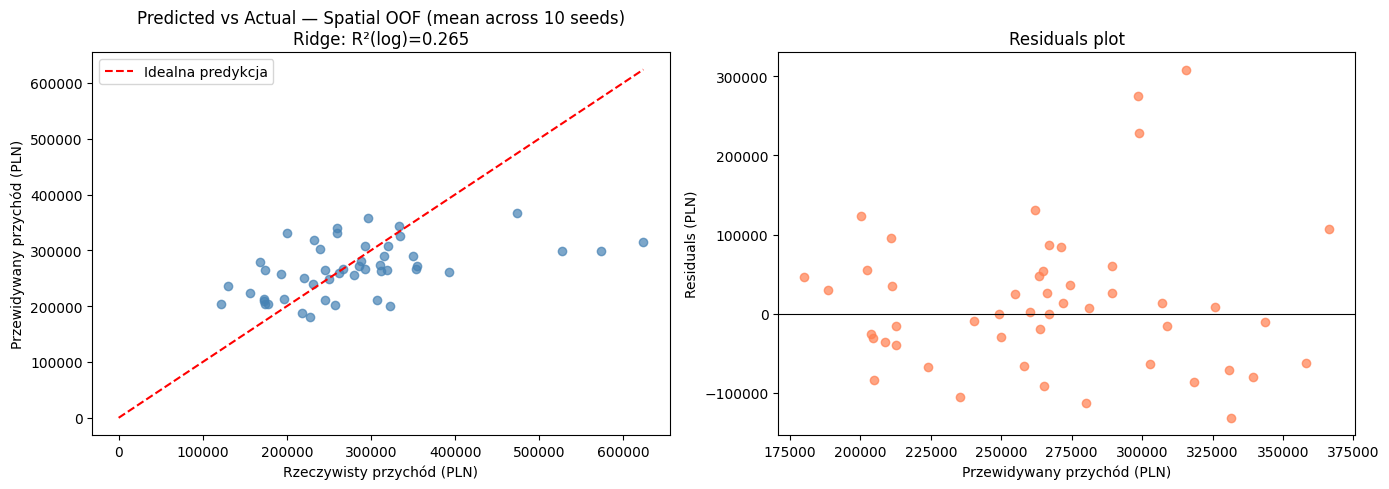

In [8]:
y_pred_log = preds_clean[best_name].mean(axis=0)
y_pred_pln = np.expm1(y_pred_log)
y_true_pln = y_raw_arr[keep]
y_true_log = y_arr[keep]
r2_log = r2_score(y_true_log, y_pred_log)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_true_pln, y_pred_pln, alpha=0.7, color='steelblue')
mx = max(y_true_pln.max(), y_pred_pln.max())
axes[0].plot([0, mx], [0, mx], 'r--', label='Idealna predykcja')
axes[0].set_xlabel('Rzeczywisty przychód (PLN)')
axes[0].set_ylabel('Przewidywany przychód (PLN)')
axes[0].set_title(f'Predicted vs Actual — Spatial OOF (mean across {preds_clean[best_name].shape[0]} seeds)\n{best_name}: R²(log)={r2_log:.3f}')
axes[0].legend()

residuals = y_true_pln - y_pred_pln
axes[1].scatter(y_pred_pln, residuals, alpha=0.7, color='coral')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Przewidywany przychód (PLN)')
axes[1].set_ylabel('Residuals (PLN)')
axes[1].set_title('Residuals plot')
plt.tight_layout()
plt.show()

In [9]:
# Porównanie: random KFold vs spatial GroupKFold — pokazuje skalę optymistycznego biasu w random split
def random_kfold_eval(X, y, k_select=12, n_seeds=10):
    rows = []
    for name, pipe in make_pipelines(k_select=min(k_select, X.shape[1])).items():
        r2s = []
        for s in range(n_seeds):
            kf = KFold(n_splits=5, shuffle=True, random_state=s)
            yp = cross_val_predict(clone(pipe), X, y, cv=kf)
            r2s.append(r2_score(y, yp))
        rows.append({'model': name, 'R²_random_KFold': np.mean(r2s), 'std_random': np.std(r2s)})
    return pd.DataFrame(rows).set_index('model')

random_results = random_kfold_eval(X_log_arr[keep], y_arr[keep], k_select=12, n_seeds=10)

comparison = pd.concat([
    random_results[['R²_random_KFold', 'std_random']],
    results_clean[['R²_mean', 'R²_std']].rename(columns={'R²_mean': 'R²_spatial', 'R²_std': 'std_spatial'}),
], axis=1)
comparison['Δ (random - spatial)'] = comparison['R²_random_KFold'] - comparison['R²_spatial']
print('Random KFold vs Spatial (GroupKFold po dzielnicy), n=49, 10 seedów:')
print(comparison.round(3).to_string())
print('\nUjemna wartość Δ → spatial lepsze; dodatnia → random nadprodukuje (przestrzenny leakage).')

Random KFold vs Spatial (GroupKFold po dzielnicy), n=49, 10 seedów:
            R²_random_KFold  std_random  R²_spatial  std_spatial  Δ (random - spatial)
model                                                                                 
Dummy                -0.045       0.034      -0.082        0.035                 0.037
Ridge                 0.291       0.079       0.199        0.104                 0.092
Lasso                 0.370       0.040       0.165        0.131                 0.205
ElasticNet            0.354       0.043       0.175        0.107                 0.178
XGBoost               0.267       0.027       0.183        0.054                 0.084

Ujemna wartość Δ → spatial lepsze; dodatnia → random nadprodukuje (przestrzenny leakage).


In [10]:
# Refit finalnego modelu na pełnym zbiorze BEZ LOC_033
final_pipeline = make_pipelines(k_select=min(final_k, X_log_arr.shape[1]))[final_model_name]
final_pipeline.fit(X_log_arr[keep], y_arr[keep])

selector = final_pipeline.named_steps.get('select')
if selector is not None:
    selected_mask = selector.get_support()
    selected_features = [feature_cols[i] for i in range(len(feature_cols)) if selected_mask[i]]
else:
    selected_features = feature_cols

print(f'Final {final_model_name} wytrenowany na n={keep.sum()} '
      f'(cechy={len(feature_cols)}, wybrane={len(selected_features)}, k={final_k})')
print(f'\nWybrane cechy:')
for f in selected_features:
    print(f'  - {f}')


Final Ridge wytrenowany na n=49 (cechy=93, wybrane=7, k=7)

Wybrane cechy:
  - active_days_2000m
  - commercial_area_3000m
  - public_area_3000m
  - commercial_count_3000m
  - commercial_area_share_3000m
  - public_area_share_3000m
  - building_floor_ratio_3000m


In [11]:
## 3.4d Slim scoring pipeline (do nb04 — tylko wybrane cechy, bez SelectKBest)
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import StandardScaler as SS

# final_pipeline ma: select → scaler → est
# scaler i est były fitowane na wyjściu SelectKBest (12 cech)
fitted_scaler = final_pipeline.named_steps['scaler']
fitted_est    = final_pipeline.named_steps['est']

slim_pipeline = SkPipeline([
    ('scaler', fitted_scaler),
    ('est',    fitted_est),
])

# Cechy wymagające log1p przed slim_pipeline
LOG_PREFIX = (
    'traces_', 'devices_', 'population_total', 'households_count',
    'buildings_count', 'total_building_area', 'poi_total', 'poi_decay_total',
    'restaurant_count', 'restaurant_decay', 'school_count', 'school_decay',
    'pharmacy_count', 'pharmacy_decay', 'bank_count', 'bank_decay',
    'hospital_count', 'hospital_decay', 'mall_count', 'mall_decay',
    'park_count', 'park_decay',
    'competitors_total', 'zabka_count', 'convenience_count', 'discount_count',
    'comp_decay_', 'population_per_km2', 'households_per_km2',
    'buildings_density_per_km2',
)
log_selected_features = [f for f in selected_features
                          if any(f.startswith(p) for p in LOG_PREFIX)]

# Sanity check: predict on training data
X_sel_log = X_log_arr[keep][:, final_pipeline.named_steps['select'].get_support()]
slim_pred = slim_pipeline.predict(X_sel_log)
slim_r2 = r2_score(y_arr[keep], slim_pred)
print(f'Slim pipeline train R² (sanity, nie CV!): {slim_r2:.3f}')
print(f'selected_features: {selected_features}')
print(f'log_selected_features: {log_selected_features}')


Slim pipeline train R² (sanity, nie CV!): 0.489
selected_features: ['active_days_2000m', 'commercial_area_3000m', 'public_area_3000m', 'commercial_count_3000m', 'commercial_area_share_3000m', 'public_area_share_3000m', 'building_floor_ratio_3000m']
log_selected_features: []


## 3.4 Explainable AI — SHAP

In [12]:
# Przygotuj dane wejściowe dla SHAP w skali, którą widzi finalny estymator
X_train_arr = X_log_arr[keep]

if best_name == 'XGBoost':
    X_after_select = final_pipeline.named_steps['select'].transform(X_train_arr)
    X_shap = pd.DataFrame(X_after_select, columns=selected_features)
    explainer = shap.TreeExplainer(final_pipeline.named_steps['est'])
    shap_values = explainer(X_shap)
elif best_name in ('Ridge', 'Lasso', 'ElasticNet'):
    X_sel = final_pipeline.named_steps['select'].transform(X_train_arr)
    X_scaled = final_pipeline.named_steps['scaler'].transform(X_sel)
    X_shap = pd.DataFrame(X_scaled, columns=selected_features)
    linear_est = final_pipeline.named_steps['est']
    explainer = shap.LinearExplainer(linear_est, X_shap, feature_perturbation='correlation_dependent')
    shap_values = explainer(X_shap)
else:
    raise RuntimeError(f'SHAP nie obsługiwany dla {best_name}')

print(f'SHAP values gotowe — model: {best_name}, shape: {shap_values.values.shape}')

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

SHAP values gotowe — model: Ridge, shape: (49, 7)


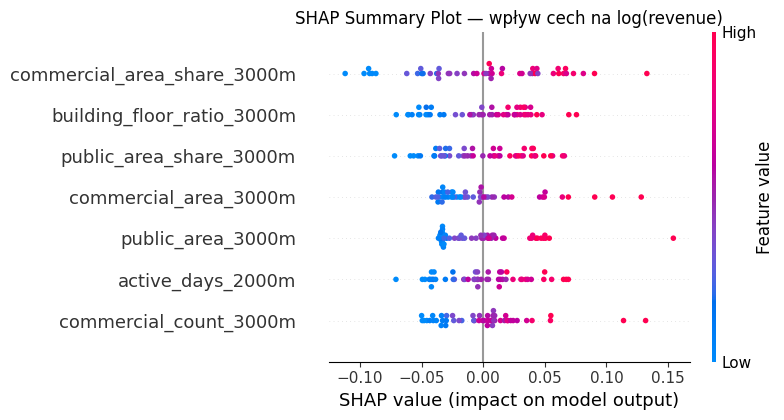

In [13]:
# Globalna ważność cech — beeswarm plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, show=False)
plt.title('SHAP Summary Plot — wpływ cech na log(revenue)')
plt.tight_layout()
plt.show()

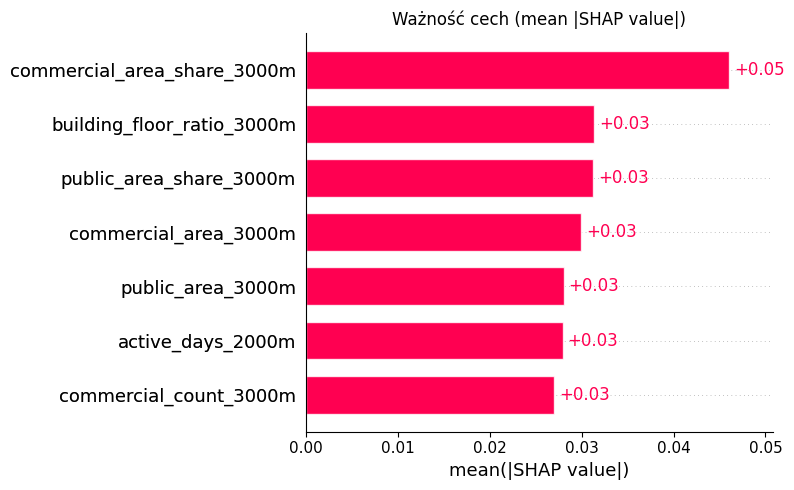

In [14]:
# Bar chart — mean |SHAP|
plt.figure(figsize=(8, 6))
shap.plots.bar(shap_values, show=False)
plt.title('Ważność cech (mean |SHAP value|)')
plt.tight_layout()
plt.show()

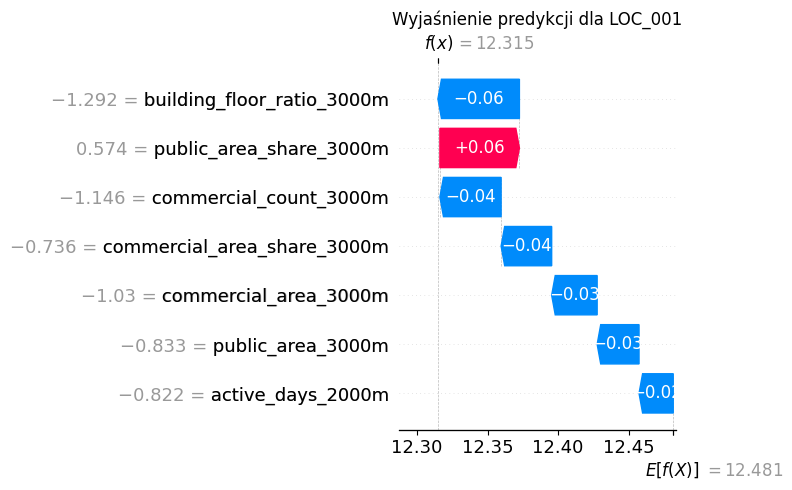

In [15]:
loc_ids_clean = features.loc[keep, 'location_id'].values
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[0], show=False)
plt.title(f'Wyjaśnienie predykcji dla {loc_ids_clean[0]}')
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

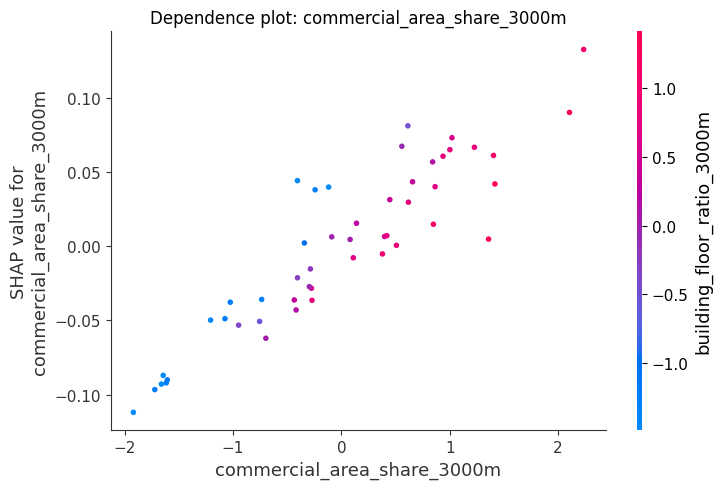

Najważniejsza cecha: commercial_area_share_3000m


In [16]:
top_feature = pd.Series(np.abs(shap_values.values).mean(axis=0), index=selected_features).idxmax()
plt.figure(figsize=(8, 5))
shap.dependence_plot(top_feature, shap_values.values, X_shap, show=False)
plt.title(f'Dependence plot: {top_feature}')
plt.tight_layout()
plt.show()
print(f'Najważniejsza cecha: {top_feature}')

In [17]:
import pickle, os
os.makedirs('../data/processed', exist_ok=True)
with open('../data/processed/model.pkl', 'wb') as f:
    pickle.dump({
        'pipeline':          final_pipeline,
        'slim_pipeline':     slim_pipeline,
        'feature_cols':      feature_cols,
        'log_features':      log_cols,
        'selected_features': selected_features,
        'log_selected':      log_selected_features,
        'log_target':        True,
        'best_name':         final_model_name,
        'best_k':            final_k,
        'cv_R2_mean':        float(best_results_k.loc[final_model_name, 'R²_mean']),
        'cv_R2_std':         float(best_results_k.loc[final_model_name, 'R²_std']),
        'cv_RMSE_PLN':       float(best_results_k.loc[final_model_name, 'RMSE_PLN']),
    }, f)
print(f'Model {final_model_name} zapisany do data/processed/model.pkl')
print(f'CV R² = {best_results_k.loc[final_model_name, "R²_mean"]:.3f} '
      f'± {best_results_k.loc[final_model_name, "R²_std"]:.3f}')
print(f'CV RMSE = {best_results_k.loc[final_model_name, "RMSE_PLN"]:,.0f} PLN')


Model Ridge zapisany do data/processed/model.pkl
CV R² = 0.216 ± 0.043
CV RMSE = 90,374 PLN
